In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# YOLO IOU and matching rate

In [99]:
iou = pd.read_csv('YOLO_accuracy.csv')
print("Average IOU: ", np.mean(iou['IOU']))
print("Std IOU: ", np.std(iou['IOU']))


Average IOU:  0.34272736004417764
Std IOU:  0.11408587074649135


Text(0, 0.5, 'Number of Volumes')

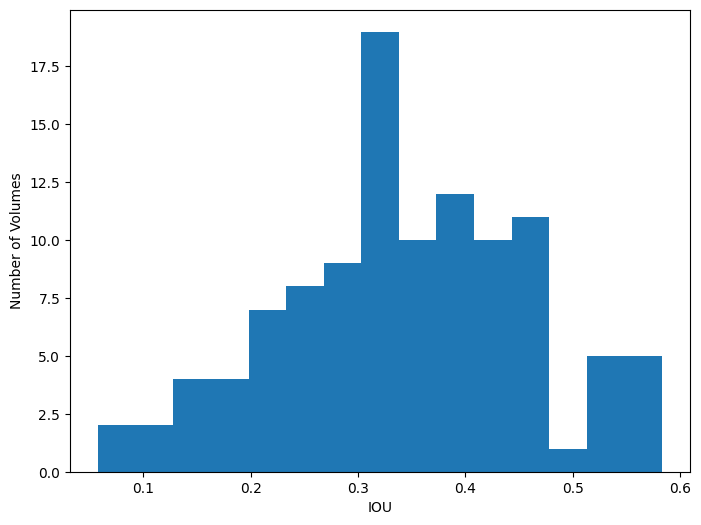

In [111]:
fig, ax = plt.subplots(1, figsize = (8, 6))
ax.hist(iou['IOU'], bins=15)
ax.set_xlabel("IOU")
ax.set_ylabel("Number of Volumes")

In [100]:
main_yolo = pd.read_csv('acc-2-yolo.csv')

mean_per_manga = main_yolo['detected'] / main_yolo['total']
print("Average Matching Rate: ", np.mean(mean_per_manga))
print("Std Matching Rate: ", np.std(mean_per_manga))

Average Matching Rate:  0.43202995009408635
Std Matching Rate:  0.1303444106763267


Text(0, 0.5, 'Number of Volumes')

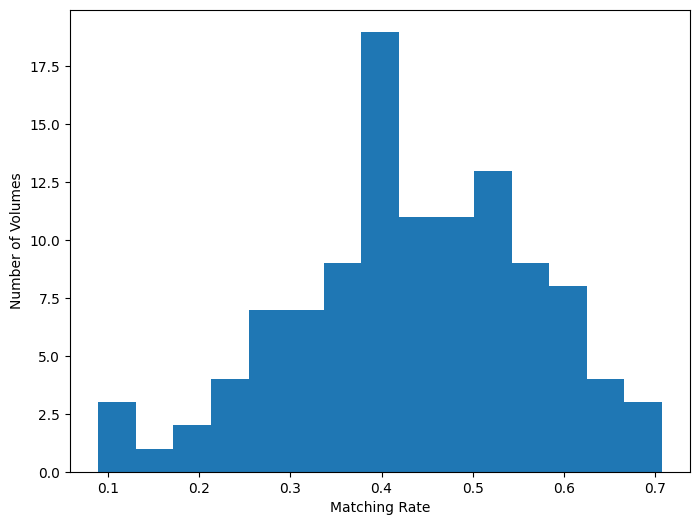

In [109]:
fig, ax = plt.subplots(1, figsize = (8, 6))
ax.hist(mean_per_manga, bins=15)
ax.set_xlabel("Matching Rate")
ax.set_ylabel("Number of Volumes")

# Encoder and Label assignment

In [101]:
from scipy.stats import ttest_ind

Average acc Frozen 0.3024971147892966
Std acc Frozen 0.12191615988024015
Average acc Trained 0.415049503727709
Std acc Trained 0.1417591335918305
Minimum improvement -0.025316455696202556
Number of Volumes with Less than 5% improvement:  22
T-statistics 6.256.


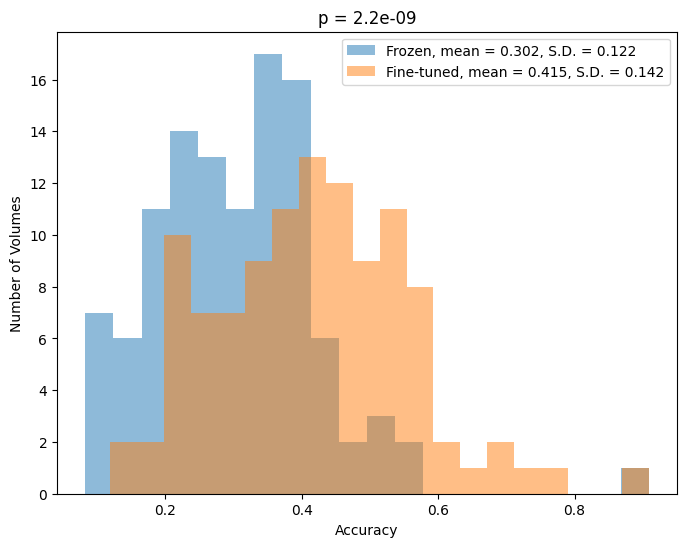

In [128]:
main16_dataset_acc = pd.read_csv('acc-2-dataset-compare.csv')
freezed_dataset_acc = pd.read_csv('acc-3-dataset-compare.csv')
# main32_dataset_acc = pd.read_csv('acc-4-dataset-compare.csv')

main16_acc = main16_dataset_acc['10']/main16_dataset_acc['num_test']
freeze_acc = freezed_dataset_acc['10']/freezed_dataset_acc['num_test']
# main32_acc = main32_dataset_acc['10']/main32_dataset_acc['num_test']

print("Average acc Frozen", np.mean(freeze_acc))
print("Std acc Frozen", np.std(freeze_acc))
print("Average acc Trained", np.mean(main16_acc))
print("Std acc Trained", np.std(main16_acc))
# print("Average acc Freeze", np.mean(main32_acc))
# print("Std acc ", np.std(main32_acc))

print("Minimum improvement", np.min(main16_acc - freeze_acc))
alpha = 0.05
print("Number of Volumes with Less than 5% improvement: ", len(main16_dataset_acc[main16_acc - freeze_acc < alpha]))
fig, ax = plt.subplots(1, figsize = (8, 6))

t_stat1, p_val1 = ttest_ind(main16_acc, freeze_acc, equal_var=False)
# t_stat2, p_val2 = ttest_ind(main32_acc, main16_acc, equal_var=True)

ax.hist(freeze_acc, label = f'Frozen, mean = {np.mean(freeze_acc):.3f}, S.D. = {np.std(freeze_acc):.3f}', bins = 20, alpha = 0.5)
ax.hist(main16_acc, label = f'Fine-tuned, mean = {np.mean(main16_acc):.3f}, S.D. = {np.std(main16_acc):.3f}', bins = 20, alpha = 0.5)
# ax.hist(main32_acc, label = f'Fine-tuned 32 (p = {p_val2:.1e}, Fine-tuned 16)', bins = 20, alpha = 0.5 )
ax.set_xlabel('Accuracy')
ax.set_ylabel('Number of Volumes')
ax.set_title(f'p = {p_val1:.1e}')
ax.legend()

print(f"T-statistics {t_stat1:.3f}.")


### Use in training vs others
We use the first 16 volumes for training.

Not used in training, mean=0.41053, S.D.=0.14053
Used in training, mean=0.44133, S.D.=0.14593


Text(0.5, 1.0, 'T-statistics = 0.674, p-value = 0.508')

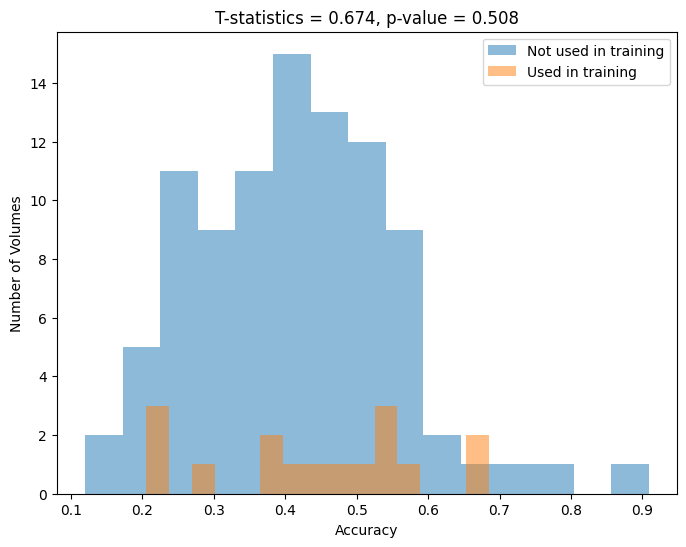

In [129]:

fig, ax = plt.subplots(1, figsize = (8, 6))

trained = main16_acc[:16]
untrained = main16_acc[16:]
ax.hist(untrained, label = f'Not used in training', bins = 15, alpha = 0.5)
ax.hist(trained, label = f'Used in training', bins = 15, alpha = 0.5)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Number of Volumes')
ax.legend()

print(f'Not used in training, mean={np.mean(untrained):.5f}, S.D.={np.std(untrained):.5f}')
print(f'Used in training, mean={np.mean(trained):.5f}, S.D.={np.std(trained):.5f}')

t_stat, p_val = ttest_ind(main16_dataset_acc['10'][:16], main16_dataset_acc['10'][16:], equal_var=False)
ax.set_title(f"T-statistics = {t_stat:.3f}, p-value = {p_val:.3f}")

### Do Training set of KNN matters?

Average acc  0.415049503727709
Std acc  0.1417591335918305
Average acc  0.4153565200816264
Std acc  0.14170282841859327


Text(0.5, 1.0, 'T-statistics = -0.016, p-value = 0.987')

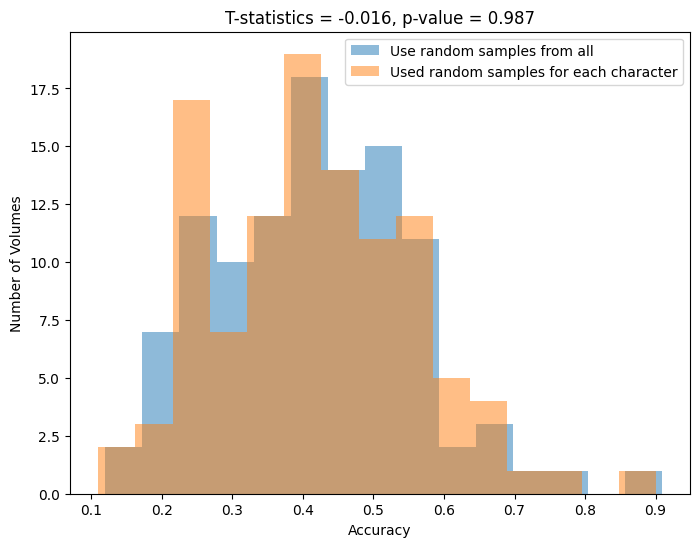

In [131]:
ds_charbase_2 = pd.read_csv('acc-2-ds-charbase.csv')

ds_charbase_2['acc'] = ds_charbase_2['10']/ds_charbase_2['num_test']

print("Average acc ", np.mean(main16_acc))
print("Std acc ", np.std(main16_acc))
print("Average acc ", np.mean(ds_charbase_2['acc']))
print("Std acc ", np.std(ds_charbase_2['acc']))

fig, ax = plt.subplots(1, figsize = (8, 6))
ax.hist(main16_acc, label = 'Use random samples from all', bins = 15, alpha = 0.5)
ax.hist(ds_charbase_2['acc'], label = 'Used random samples for each character', bins = 15, alpha = 0.5)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Number of Volumes')
ax.legend()


t_stat, p_val = ttest_ind(main16_acc, ds_charbase_2['acc'], equal_var=False)
ax.set_title(f"T-statistics = {t_stat:.3f}, p-value = {p_val:.3f}")

In [126]:
main16_dataset_acc['ratio'] = main16_acc
sorted = main16_dataset_acc.sort_values(by = 'ratio')
sorted[['name', '10', 'total']]

,name,10,total
95,TouyouKidan,148,1236
50,MariaSamaNihaNaisyo,74,580
24,Hamlet,356,2056
40,KoukouNoHitotachi,339,1707
4,AosugiruHaru,104,506
...,...,...,...
74,ReveryEarth,499,737
13,Count3DeKimeteAgeru,430,628
72,PsychoStaff,438,604
19,EverydayOsakanaChan,344,436


# Full pipeline 

## YOLO

Average acc  0.30119179725879214
Std acc  0.15941913626262233


/var/folders/g9/wp93t1xs2s76mg2jyn0x1qjh0000gn/T/ipykernel_1807/2569544608.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


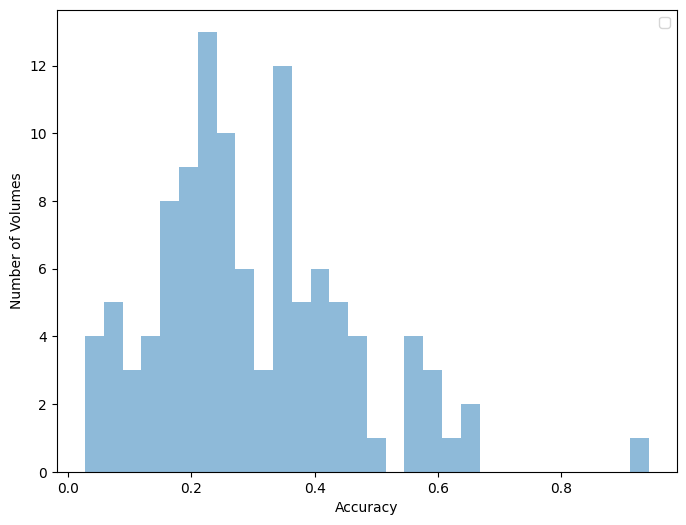

In [133]:
yolo_charbase_2 = pd.read_csv('acc-2-yolo-charbase.csv')
yolo_charbase_2['acc'] = yolo_charbase_2['10']/ds_charbase_2['num_test']

print("Average acc ", np.mean(yolo_charbase_2['acc']))
print("Std acc ", np.std(yolo_charbase_2['acc']))

fig, ax = plt.subplots(1, figsize = (8, 6))
ax.hist(yolo_charbase_2['acc'], bins = 30, alpha = 0.5)

ax.set_xlabel('Accuracy')
ax.set_ylabel('Number of Volumes')
ax.legend()

# Number of characters against accuracy

Text(0, 0.5, 'Whole Pipeline Accuracy')

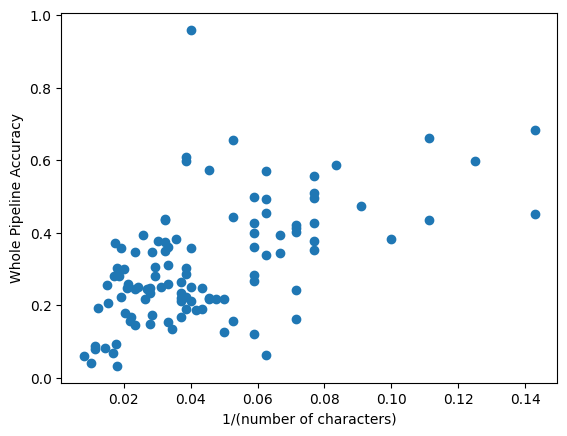

In [82]:
num_chars = pd.read_csv('num_chars.csv')
plt.scatter(1/num_chars['num_characters'], yolo_charbase_2['acc'])
plt.xlabel('1/(number of characters)')
plt.ylabel('Whole Pipeline Accuracy')